Lets create a NERF from scatch!

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import numpy as np
from torch.utils.data import DataLoader, Dataset, TensorDataset
from PIL import Image
import matplotlib.pyplot as plt
import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)



cuda


In [21]:
# Create our mlp
# We input a 2d point and get the color for it, meaning 3d output rgb

# Positional encoding
# Here we just concat x with the sin and cos of L*2 amount of frequencies
class PE(nn.Module):
    def __init__(self, L=10):
        super(PE, self).__init__()
        self.L = L

    def forward(self, x):
        out = x
        for i in range(self.L):
            out = torch.cat([out, torch.sin(torch.pi * x * 2**i), torch.cos(torch.pi * x * 2**i)], dim=-1)
        return out


class MLP(torch.nn.Module):
    def __init__(self, input_size, hidden_size=256, L=40):
        super(MLP, self).__init__()
        self.mlp = torch.nn.Sequential(
            PE(L=L),
            nn.Linear((L*2+1)*input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 3),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.mlp(x)

torch.Size([689, 1024, 3])


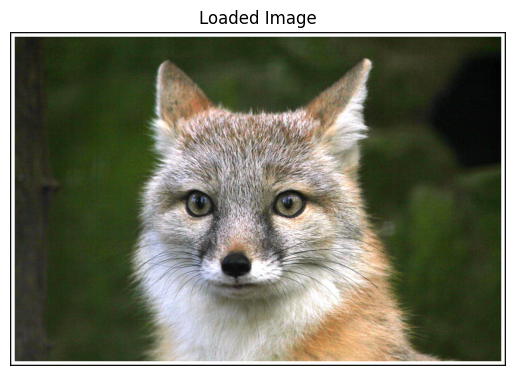

In [22]:
image = Image.open('data/fox.jpg')

# Transform: Convert to tensor
transform = transforms.ToTensor()
image_tensor = transform(image).permute(1, 2, 0)
print(image_tensor.shape)
# Display the image
plt.imshow(image_tensor)
plt.axis('off')  # Turn off the axis
plt.title("Loaded Image")
plt.show()


In [23]:
# Create DataLoader
image = np.array(Image.open('data/fox.jpg'))
height, width, _ = image.shape
# Normalized to 0-1:
ourgrid = torch.meshgrid(
        torch.linspace(0, 1, steps=height),
        torch.linspace(0, 1, steps=width),
        indexing="ij"
    )
# height width
hw = torch.stack(ourgrid, dim=-1).reshape(-1, 2)
label = torch.tensor(image / 255., dtype=torch.float32).reshape(-1, 3)
pixeldataset = TensorDataset(hw, label)
train_loader = DataLoader(pixeldataset, batch_size=10000, shuffle=True)


In [24]:
def sample_image(model, image_shape):
    with torch.no_grad():
        gen_image = model(hw.to(device)).cpu().numpy()
    return (gen_image.reshape(image_shape) * 255).astype(np.uint8)

Iteration 0, Loss: 0.10413727909326553
Iteration 1, Loss: 0.14126114547252655
Iteration 2, Loss: 0.08287363499403
Iteration 3, Loss: 0.09153429418802261
Iteration 4, Loss: 0.08911246806383133
Iteration 5, Loss: 0.08345963060855865
Iteration 6, Loss: 0.07280043512582779
Iteration 7, Loss: 0.06448378413915634
Iteration 8, Loss: 0.06300178170204163
Iteration 9, Loss: 0.06181291118264198
Iteration 10, Loss: 0.058726124465465546
Iteration 11, Loss: 0.049498673528432846
Iteration 12, Loss: 0.05111337825655937
Iteration 13, Loss: 0.05200977250933647
Iteration 14, Loss: 0.050835877656936646
Iteration 15, Loss: 0.05063687637448311
Iteration 16, Loss: 0.0487993098795414
Iteration 17, Loss: 0.04727581515908241
Iteration 18, Loss: 0.047102101147174835
Iteration 19, Loss: 0.04587101191282272
Iteration 20, Loss: 0.04481848329305649
Iteration 21, Loss: 0.044105298817157745
Iteration 22, Loss: 0.04406125470995903
Iteration 23, Loss: 0.0423881970345974
Iteration 24, Loss: 0.040887173265218735
Iteration

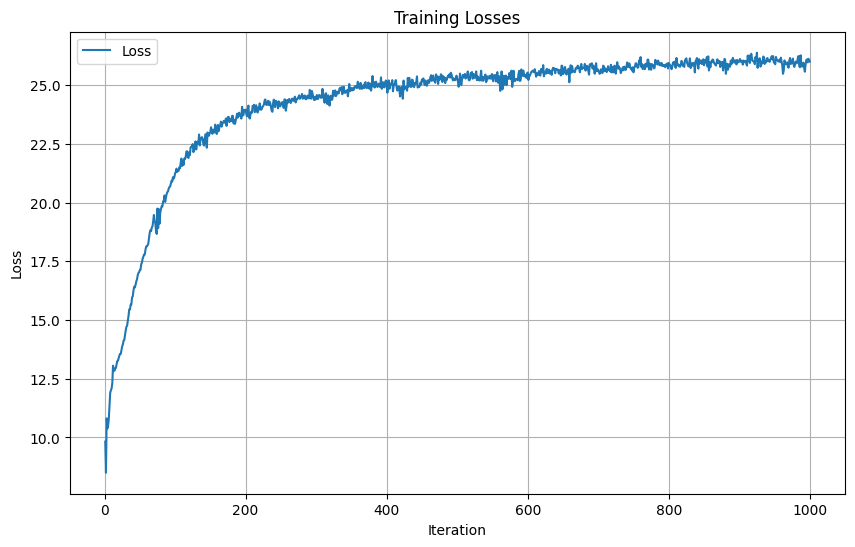

In [25]:
def compute_psnr(mse):
    return 10 * np.log10(1. / mse)

# Training loop
def train(train_loader, hidden_dim=256, lr=1e-2, num_iterations=1000):
    # Initialize components
    model = MLP(input_size=2, hidden_size=hidden_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    dataloader = train_loader
    losses = []
    steps = []
    # Training loop
    for iteration in range(num_iterations):
        hw, colors = next(iter(train_loader))
        hw = hw.to(device)
        colors = colors.to(device)

        # Forward pass
        preds = model(hw)
        loss = criterion(preds, colors)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Iteration {iteration}, Loss: {loss.item()}")
        losses.append(compute_psnr(loss.item()))
        steps.append(iteration + 1)
        if (iteration + 1) % 100 == 0 or iteration == 9:
            output_image = sample_image(model, image_shape=image.shape)
            Image.fromarray(output_image).save(f"output/{iteration + 1}generated_image.png")

    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, label='Loss')

    plt.title('Training Losses')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    # plt.yscale('log')
    plt.grid(True)
    plt.legend()

    plt.show()
    return model

model = train(train_loader)

In [ ]:
output_image = sample_image(model, image_shape=image.shape)
Image.fromarray(output_image).save("output/generated_image.png")

# Visualize the output
plt.imshow(output_image)
plt.axis('off')
plt.show()

# Save the generated image
from PIL import Image
Image.fromarray(output_image).save("generated_image.png")

